In [1]:
import itertools
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

prices = pd.read_csv("prices.txt", sep=r"\s+")
returns = prices.pct_change()
assets = prices.columns.tolist()

# Keep optimisation/selection clean: train on first 250 price rows only.
train_end = len(prices) - 250
train_prices = prices.iloc[:train_end]

print("Assets:", len(assets))
print("Train rows:", len(train_prices))
print("Triples to scan:", len(list(itertools.combinations(assets, 3))))


Assets: 51
Train rows: 250
Triples to scan: 20825


In [2]:
triple_rows = []

for asset_y, asset_x1, asset_x2 in itertools.combinations(assets, 3):
    y = train_prices[asset_y]
    x = sm.add_constant(train_prices[[asset_x1, asset_x2]])

    model = sm.OLS(y, x).fit()
    train_spread = model.resid
    adf_stat, adf_p_value, *_ = adfuller(train_spread.dropna())

    triple_rows.append({
        "asset_y": asset_y,
        "asset_x1": asset_x1,
        "asset_x2": asset_x2,
        "alpha": model.params["const"],
        "beta_x1": model.params[asset_x1],
        "beta_x2": model.params[asset_x2],
        "adf_stat": adf_stat,
        "adf_p_value": adf_p_value,
        "r_squared": model.rsquared,
        "spread_std": train_spread.std(),
    })

triple_results = pd.DataFrame(triple_rows).sort_values(
    ["adf_p_value", "r_squared"],
    ascending=[True, False],
)

display(triple_results.head(30))


,asset_y,asset_x1,asset_x2,alpha,beta_x1,beta_x2,adf_stat,adf_p_value,r_squared,spread_std
1939,AENO,NWIG,RRES,48.073182,0.742036,-0.578036,-6.537653,9.519534e-09,0.839304,3.470689
10970,NPCK,MSDP,HRND,5.999394,0.327372,-0.090179,-5.939621,2.277282e-07,0.781590,0.945002
10956,NPCK,MSDP,RRES,3.241125,0.406834,-0.054076,-5.920825,2.508933e-07,0.762057,0.986352
10962,NPCK,MSDP,RCRI,2.668258,0.482708,-0.076632,-5.868462,3.282872e-07,0.783862,0.940073
1952,AENO,NWIG,EELT,40.795051,0.672474,-0.086720,-5.677152,8.652116e-07,0.816664,3.707128
20665,ULXY,BLBT,FCSG,112.646546,-0.590156,-1.271986,-5.664300,9.227067e-07,0.621983,3.023001
1940,AENO,NWIG,CTGI,39.225910,0.676842,-0.075699,-5.655180,9.657513e-07,0.813847,3.735497
20701,ULXY,FCSG,EAFC,97.591184,-0.963890,-0.563658,-5.624260,1.126770e-06,0.635032,2.970366
10685,SMAH,ACAC,HTRK,-54.795063,0.582845,5.393466,-5.604875,1.240776e-06,0.916818,2.411676
6228,AMRP,MMBT,EAFC,16.226773,-0.064615,0.314416,-5.586408,1.359803e-06,0.769673,1.567769


In [3]:
stationary_triples = triple_results[
    (triple_results["adf_p_value"] < 0.05) &
    (triple_results["r_squared"] > 0.50)
].copy()

# Pick strongest non-overlapping baskets to reduce concentration/duplicate exposure.
max_triples = 10
used_assets = set()
selected_rows = []

for _, row in stationary_triples.iterrows():
    basket_assets = {row["asset_y"], row["asset_x1"], row["asset_x2"]}
    if used_assets & basket_assets:
        continue

    selected_rows.append(row)
    used_assets.update(basket_assets)

    if len(selected_rows) >= max_triples:
        break

selected_triples = pd.DataFrame(selected_rows).reset_index(drop=True)

print("Stationary triples found:", len(stationary_triples))
print("Selected non-overlapping triples:", len(selected_triples))
display(selected_triples)


Stationary triples found: 2840
Selected non-overlapping triples: 10


,asset_y,asset_x1,asset_x2,alpha,beta_x1,beta_x2,adf_stat,adf_p_value,r_squared,spread_std
0,AENO,NWIG,RRES,48.073182,0.742036,-0.578036,-6.537653,9.519534e-09,0.839304,3.470689
1,NPCK,MSDP,HRND,5.999394,0.327372,-0.090179,-5.939621,2.277282e-07,0.781590,0.945002
2,ULXY,BLBT,FCSG,112.646546,-0.590156,-1.271986,-5.664300,9.227067e-07,0.621983,3.023001
3,SMAH,ACAC,HTRK,-54.795063,0.582845,5.393466,-5.604875,1.240776e-06,0.916818,2.411676
4,AMRP,MMBT,EAFC,16.226773,-0.064615,0.314416,-5.586408,1.359803e-06,0.769673,1.567769
5,ACIX,ITPA,NGTE,2.617299,0.797552,-0.031064,-5.489509,2.191360e-06,0.907231,0.469925
6,CTGI,ALUT,ILVX,-5.381217,1.200913,2.187555,-5.194232,9.033621e-06,0.785126,5.331132
7,GARI,MTNS,EELT,17.065865,0.265662,-0.076948,-5.165005,1.035977e-05,0.620485,0.815795
8,DIHO,CCNS,AETS,2.465074,0.161933,0.174556,-4.915469,3.253545e-05,0.717681,0.542325
9,HETT,CUBO,IHOZ,42.159444,0.473931,-0.255059,-4.472779,2.201508e-04,0.775238,3.247575


In [4]:
def build_tuple_positions(prices, selected_triples, rolling_window=60, z_scale=0.75, dead_zone=0.25):
    positions = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
    basket_allocations = []

    for _, triple in selected_triples.iterrows():
        y = triple["asset_y"]
        x1 = triple["asset_x1"]
        x2 = triple["asset_x2"]
        alpha = triple["alpha"]
        beta1 = triple["beta_x1"]
        beta2 = triple["beta_x2"]

        spread = prices[y] - alpha - beta1 * prices[x1] - beta2 * prices[x2]
        spread_mean = spread.shift(1).rolling(rolling_window).mean()
        spread_std = spread.shift(1).rolling(rolling_window).std()
        z = (spread.shift(1) - spread_mean) / spread_std.replace(0, np.nan)

        strength = -np.tanh(z / z_scale)
        strength = strength.where(z.abs() >= dead_zone, 0.0).fillna(0.0)

        gross = 1 + abs(beta1) + abs(beta2)
        basket = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
        basket[y] = strength / gross
        basket[x1] = -strength * beta1 / gross
        basket[x2] = -strength * beta2 / gross

        basket_allocations.append((strength.abs(), basket))

    if not basket_allocations:
        return positions

    total_strength = sum(scale for scale, _ in basket_allocations).replace(0, np.nan)

    for scale, basket in basket_allocations:
        capital_share = (scale / total_strength).fillna(0.0)
        positions += basket.mul(capital_share, axis=0)

    return positions


tuple_positions = build_tuple_positions(
    prices,
    selected_triples,
    rolling_window=60,
    z_scale=0.75,
    dead_zone=0.25,
)

tuple_strategy_returns = (tuple_positions * returns).sum(axis=1).dropna()
train_tuple_returns = tuple_strategy_returns.iloc[:train_end]
test_tuple_returns = tuple_strategy_returns.iloc[train_end:]

display(tuple_positions.tail())


,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
495,0.0,0.041474,0.0,0.0,0.0,-0.081238,0.0,0.070480,0.0,0.0,...,0.023173,0.0,0.046363,-0.090717,-0.001806,0.000000,0.049946,0.0,0.0,0.025543
496,0.0,0.019034,0.0,0.0,0.0,-0.084336,0.0,0.078610,0.0,0.0,...,0.023367,0.0,0.054846,-0.103132,-0.002136,0.000000,0.050363,0.0,0.0,0.026517
497,0.0,0.000000,0.0,0.0,0.0,-0.100255,0.0,0.086131,0.0,0.0,...,0.017980,0.0,0.063886,-0.114613,-0.002488,0.000000,0.038753,0.0,0.0,0.031522
498,0.0,0.036838,0.0,0.0,0.0,-0.089956,0.0,0.071558,0.0,0.0,...,0.011254,0.0,0.049633,-0.095814,-0.001933,0.000000,0.024257,0.0,0.0,0.028284
499,0.0,0.000000,0.0,0.0,0.0,-0.113438,0.0,0.080146,0.0,0.0,...,0.003824,0.0,0.042180,-0.102143,-0.001643,-0.014281,0.008243,0.0,0.0,0.035667


,train,test,all
mean_daily_return,0.002274,0.000521,0.001397
daily_volatility,0.003848,0.004310,0.004175
annualised_sharpe,9.341197,1.913034,5.293086
total_return,0.761057,0.136569,1.001562


<Axes: title={'center': 'Tuple basket strategy cumulative return'}>

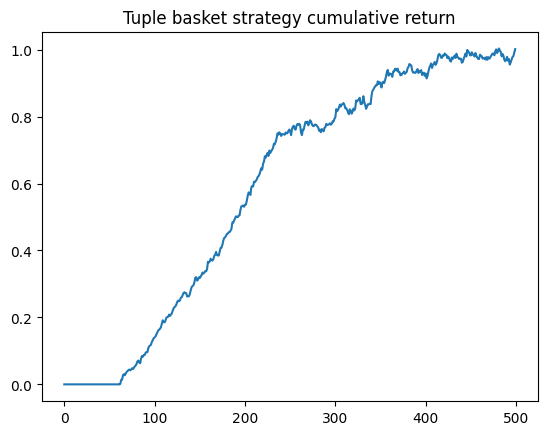

In [5]:
def sharpe_ratio(return_series):
    daily_volatility = return_series.std()
    if daily_volatility <= 0 or pd.isna(daily_volatility):
        return np.nan
    return np.sqrt(250) * return_series.mean() / daily_volatility


def performance_summary(return_series):
    return pd.Series({
        "mean_daily_return": return_series.mean(),
        "daily_volatility": return_series.std(),
        "annualised_sharpe": sharpe_ratio(return_series),
        "total_return": (1 + return_series).prod() - 1,
    })


summary = pd.DataFrame({
    "train": performance_summary(train_tuple_returns),
    "test": performance_summary(test_tuple_returns),
    "all": performance_summary(tuple_strategy_returns),
})

display(summary)

cumulative_tuple_returns = (1 + tuple_strategy_returns).cumprod() - 1
cumulative_tuple_returns.plot(title="Tuple basket strategy cumulative return")
